# SC5006 Project 1 — CountGD Component Analysis and Open-World Counting

**Team size:** 1–5 students  
**Foundation model:** [CountGD](https://github.com/niki-amini-naieni/CountGD), NeurIPS 2024  
**Test images:** `women.jpg` and `car.jpg`  
**Required evidence:** component shapes/visualizations, live-model predictions, quantitative results, and failure analysis

The project studies five linked CountGD components. A five-person team should assign one primary owner to each component; smaller teams combine roles. Every member must understand the integrated pipeline and speak during the oral presentation.

| Role | Assessed component | Main evidence |
|---|---|---|
| A | Image encoder | multi-scale features and combined 1/8-scale feature map |
| B | Text encoder | tokenization, masks, and projected BERT tokens |
| C | ROIAlign | pixel-space exemplar box and extracted visual token |
| D | Similarity matrix | query–prompt logits and padding mask |
| E | Top-K selection | ranked encoder proposals and prompt IDs |

The shared integration experiment runs the official CountGD checkpoint on women (text prompt) and cars (text-only, exemplar-only, and multimodal prompts), then applies the official confidence threshold and counting rule.

## Deliverables

Submit three files named with your team name:

1. `TeamXX_SC5006_Project1.ipynb` — completed code, outputs, plots, and brief interpretations.
2. `TeamXX_SC5006_Project1_Report.pdf` — Title, Authors, Introduction, Related Work, Method, Experiments, Results and Discussion, Conclusion, References, and contribution statement.
3. `TeamXX_SC5006_Project1_Presentation.pptx` — a 10-minute oral presentation; 1-2 members do the presentation; but all members must join the Q&A.

The report should be 6–8 pages excluding references/appendix. The presentation should contain 8–15 content slides. Results must distinguish live-model evidence from cached reference outputs.


## 0. Environment and model setup

Run the cell below from the project folder. It downloads the official CountGD FSC-147 checkpoint and BERT encoder only when missing, verifies the checkpoint SHA-256, loads all model weights, and prints the active paths and device. Internet access is needed only for the first run.


In [1]:
from pathlib import Path
import hashlib, importlib, os, subprocess, sys, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import torch
import torch.nn.functional as F

warnings.filterwarnings("ignore")

# Open the notebook from the distributed project folder.
ROOT = Path.cwd().resolve()
if not (ROOT / "assets/reference/car.jpg").is_file():
    raise FileNotFoundError("Open this notebook from the Project 1 folder.")

ASSETS = ROOT / "assets/reference"
OUTPUT = ROOT / "output/figures"
CHECKPOINTS = ROOT / "checkpoints"
CHECKPOINT = CHECKPOINTS / "checkpoint_fsc147_best.pth"
BERT = CHECKPOINTS / "bert-base-uncased"
COUNTGD_ROOT = ROOT / "vendor/countgd"
OUTPUT.mkdir(parents=True, exist_ok=True)
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE_ID = "1RbRcNLsOfeEbx6u39pBehqsgQiexHHrI"
EXPECTED_CHECKPOINT_SHA256 = "c1bab864b17db345b4c6e3aaabb5765bc2c0a90d0bc8defb5e664a74a50aa126"

def require_package(module, package=None):
    try:
        return importlib.import_module(module)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package or module])
        return importlib.import_module(module)

def download_missing_assets():
    if not CHECKPOINT.is_file():
        print("Downloading the official CountGD FSC-147 checkpoint (1.2 GB)...")
        gdown = require_package("gdown")
        result = gdown.download(id=CHECKPOINT_FILE_ID, output=str(CHECKPOINT), quiet=False)
        if not result or not CHECKPOINT.is_file():
            raise RuntimeError("Official CountGD checkpoint download failed.")
    if not (BERT / "config.json").is_file():
        print("Downloading the official BERT base encoder...")
        huggingface_hub = require_package("huggingface_hub")
        huggingface_hub.snapshot_download(
            repo_id="google-bert/bert-base-uncased", local_dir=str(BERT)
        )

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

download_missing_assets()
CHECKPOINT_SHA256 = sha256_file(CHECKPOINT)
if CHECKPOINT_SHA256 != EXPECTED_CHECKPOINT_SHA256:
    raise RuntimeError(f"Incorrect CountGD checkpoint SHA-256: {CHECKPOINT_SHA256}")
if not (COUNTGD_ROOT / "models/GroundingDINO/groundingdino.py").is_file():
    raise FileNotFoundError("The distributed official source snapshot vendor/countgd is incomplete.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sys.path.insert(0, str(COUNTGD_ROOT))
import datasets_inference.transforms as T
from util.slconfig import SLConfig
from util.misc import nested_tensor_from_tensor_list
from models.GroundingDINO.groundingdino import build_groundingdino
from models.GroundingDINO.bertwarper import generate_masks_with_special_tokens_and_transfer_map
from torchvision.ops import roi_align

TRANSFORM = T.Compose([
    T.RandomResize([800], max_size=1333),
    T.Compose([T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
])

def prepare_case(name, image_name, text="", boxes=()):
    image = Image.open(ASSETS / image_name).convert("RGB")
    clean = " ".join(text.lower().strip().rstrip(".").split())
    boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    if len(boxes) > 3:
        raise ValueError("CountGD supports at most three exemplars")
    if boxes.numel():
        x1, y1, x2, y2 = boxes.unbind(1)
        valid = (x2 > x1) & (y2 > y1) & (x1 >= 0) & (y1 >= 0) & (x2 <= image.width) & (y2 <= image.height)
        if not bool(valid.all()):
            raise ValueError("Exemplars must be positive-area pixel xyxy boxes inside the image")
    mode = "text + exemplar" if clean and len(boxes) else ("text only" if clean else "exemplar only")
    return {"name": name, "image_name": image_name, "image": image,
            "caption": f"{clean} ." if clean else "object .", "boxes": boxes, "mode": mode}

def preprocess_case(case):
    image_tensor, target = TRANSFORM(case["image"], {"exemplars": case["boxes"].clone()})
    return image_tensor, target["exemplars"].to(torch.float32).reshape(-1, 4)

def load_model():
    cfg = SLConfig.fromfile(str(COUNTGD_ROOT / "config/cfg_fsc147_vit_b.py"))
    cfg.device, cfg.text_encoder_type = str(DEVICE), str(BERT)
    model, _, _ = build_groundingdino(cfg)
    message = model.load_state_dict(torch.load(CHECKPOINT, map_location="cpu")["model"], strict=False)
    if message.missing_keys or message.unexpected_keys:
        raise RuntimeError(f"Checkpoint mismatch: {message}")
    return model.to(DEVICE).eval()

CASES = [
    prepare_case("women_text", "women.jpg", text="women"),
    prepare_case("car_text", "car.jpg", text="car"),
    prepare_case("car_exemplar", "car.jpg", boxes=[[55, 72, 151, 218]]),
    prepare_case("car_multimodal", "car.jpg", text="car", boxes=[[55, 72, 151, 218]]),
]
MODEL = load_model()
print("team project root:", ROOT)
print("CountGD source:", COUNTGD_ROOT)
print("checkpoint:", CHECKPOINT)
print("checkpoint SHA-256:", CHECKPOINT_SHA256)
print("BERT:", BERT)
print("device:", DEVICE, "| live official model: True")
for case in CASES:
    print(case["name"], case["mode"], repr(case["caption"]), tuple(case["boxes"].shape))


final text_encoder_type: /home/misaki/SC5006_Lab/MultiModalCounting/checkpoints/bert-base-uncased
load tokenizer done.
final text_encoder_type: /home/misaki/SC5006_Lab/MultiModalCounting/checkpoints/bert-base-uncased
load tokenizer done.
team project root: /home/misaki/SC5006_Lab/MultiModalCounting
CountGD source: /home/misaki/SC5006_Lab/MultiModalCounting/vendor/countgd
checkpoint: /home/misaki/SC5006_Lab/MultiModalCounting/checkpoints/checkpoint_fsc147_best.pth
checkpoint SHA-256: c1bab864b17db345b4c6e3aaabb5765bc2c0a90d0bc8defb5e664a74a50aa126
BERT: /home/misaki/SC5006_Lab/MultiModalCounting/checkpoints/bert-base-uncased
device: cpu | live official model: True
women_text text only 'women .' (0, 4)
car_text text only 'car .' (0, 4)
car_exemplar exemplar only 'object .' (1, 4)
car_multimodal text + exemplar 'car .' (1, 4)


## Task 1 — Image encoder (15%)

Implement `encode_image`. Convert a preprocessed image batch into CountGD's nested-tensor representation, run the official Swin backbone, and combine the multi-scale features into the 1/8-scale feature map used for exemplar extraction.

**TODO 1**

- accept `(B,3,H,W)` or a list of `(3,H,W)` tensors;
- call `nested_tensor_from_tensor_list` and `model.backbone`;
- call `model.combine_features`;
- return the backbone features, positional encodings, and combined feature map; and
- report shapes and visualize mean feature activation.

combined image features: (1, 256, 100, 134)


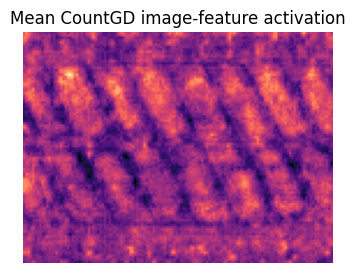

In [2]:
def encode_image(model, image_batch):
    if isinstance(image_batch, torch.Tensor):
        image_batch = list(image_batch)
    samples = nested_tensor_from_tensor_list(image_batch).to(DEVICE)
    with torch.inference_mode():
        features, positions = model.backbone(samples)
        combined = model.combine_features(features)
    assert combined.ndim == 4 and combined.shape[1] == model.hidden_dim
    return features, positions, combined

car_tensor, car_boxes_resized = preprocess_case(CASES[-1])
IMAGE_FEATURES, IMAGE_POSITIONS, COMBINED_FEATURES = encode_image(MODEL, car_tensor.unsqueeze(0))
print("combined image features:", tuple(COMBINED_FEATURES.shape))
plt.figure(figsize=(6, 3)); plt.imshow(COMBINED_FEATURES[0].mean(0).detach().cpu(), cmap="magma")
plt.title("Mean CountGD image-feature activation"); plt.axis("off"); plt.show()


## Task 2 — Text encoder (15%)

Implement `encode_text` by reproducing CountGD's caption path: tokenize, build special-token attention structures, run BERT, and project the last hidden state to the shared model dimension.

**TODO 2**

- tokenize a caption batch with padding;
- build self-attention masks and position IDs using the repository helper;
- run `model.bert` and `model.feat_map`;
- return encoded prompt tokens and the valid-token mask; and
- identify which columns correspond to real prompt tokens rather than padding.

In [3]:
def encode_text(model, captions):
    if isinstance(captions, str):
        captions = [captions]
    if not captions or any(not c.strip() for c in captions):
        raise ValueError("encode_text expects a non-empty list of non-empty captions")
 
    tokenized = model.tokenizer(captions, padding="longest", return_tensors="pt").to(DEVICE)
    self_masks, position_ids, _ = generate_masks_with_special_tokens_and_transfer_map(
        tokenized, model.specical_tokens, model.tokenizer)
 
    # Official Grounding DINO / CountGD behaviour: cut everything to max_text_len.
    max_len = getattr(model, "max_text_len", 256)
    if self_masks.shape[1] > max_len:
        self_masks = self_masks[:, :max_len, :max_len]
        position_ids = position_ids[:, :max_len]
        for key in ("input_ids", "attention_mask", "token_type_ids"):
            if key in tokenized:
                tokenized[key] = tokenized[key][:, :max_len]
 
    tokenized_for_encoder = {k: v for k, v in tokenized.items() if k != "attention_mask"}
    tokenized_for_encoder["attention_mask"] = self_masks
    tokenized_for_encoder["position_ids"] = position_ids
    with torch.inference_mode():
        bert_output = model.bert(**tokenized_for_encoder)
        encoded = model.feat_map(bert_output["last_hidden_state"])   # 768 -> 256
    valid = tokenized.attention_mask.bool()                         # False = [PAD]
    return {"encoded_text": encoded, "text_token_mask": valid,
            "position_ids": position_ids, "text_self_attention_masks": self_masks,
            "input_ids": tokenized.input_ids}
 
if MODEL is not None:
    TEXT_DICT = encode_text(MODEL, ["car ."])
else:
    TEXT_DICT = {"encoded_text": torch.randn(1, 4, 256),
                 "text_token_mask": torch.tensor([[True, True, True, True]])}
print("encoded text:", tuple(TEXT_DICT["encoded_text"].shape),
      "valid tokens:", int(TEXT_DICT["text_token_mask"].sum()))


encoded text: (1, 4, 256) valid tokens: 4


In [4]:
MAX_LEN = getattr(MODEL, "max_text_len", 256)
HIDDEN = MODEL.hidden_dim
 
# 1) Normal caption keeps its shape.
assert tuple(TEXT_DICT["encoded_text"].shape) == (1, 4, HIDDEN)
 
# 2) Truncation: a caption much longer than max_text_len is cut to exactly MAX_LEN.
long_out = encode_text(MODEL, [" ".join(["car"] * 300) + " ."])
assert tuple(long_out["encoded_text"].shape) == (1, MAX_LEN, HIDDEN), long_out["encoded_text"].shape
assert tuple(long_out["text_self_attention_masks"].shape) == (1, MAX_LEN, MAX_LEN)
assert tuple(long_out["position_ids"].shape) == (1, MAX_LEN)
assert tuple(long_out["text_token_mask"].shape) == (1, MAX_LEN)
 
# 3) Empty input is rejected.
for bad in ([], [""], ["   "]):
    try:
        encode_text(MODEL, bad)
        raise AssertionError(f"empty input {bad!r} was accepted")
    except ValueError:
        pass
 
print(f"Task 2 tests passed: normal (1,4,{HIDDEN}), truncated (1,{MAX_LEN},{HIDDEN}), empty input rejected")


Task 2 tests passed: normal (1,4,256), truncated (1,256,256), empty input rejected


batch of 3 captions padded to length 8; encoded_text: (3, 8, 256)

'car .'  real tokens=4  padded=4
  col    token     id  valid  pos
    0    [CLS]    101   True    0
    1      car   2482   True    0
    2        .   1012   True    1
    3    [SEP]    102   True    0
    4    [PAD]      0  False    0
    5    [PAD]      0  False    0
    6    [PAD]      0  False    0
    7    [PAD]      0  False    0

'yellow car .'  real tokens=5  padded=3
  col    token     id  valid  pos
    0    [CLS]    101   True    0
    1   yellow   3756   True    0
    2      car   2482   True    1
    3        .   1012   True    2
    4    [SEP]    102   True    0
    5    [PAD]      0  False    0
    6    [PAD]      0  False    0
    7    [PAD]      0  False    0

'red car . white car .'  real tokens=8  padded=0
  col    token     id  valid  pos
    0    [CLS]    101   True    0
    1      red   2417   True    0
    2      car   2482   True    1
    3        .   1012   True    2
    4    white   2317   Tru

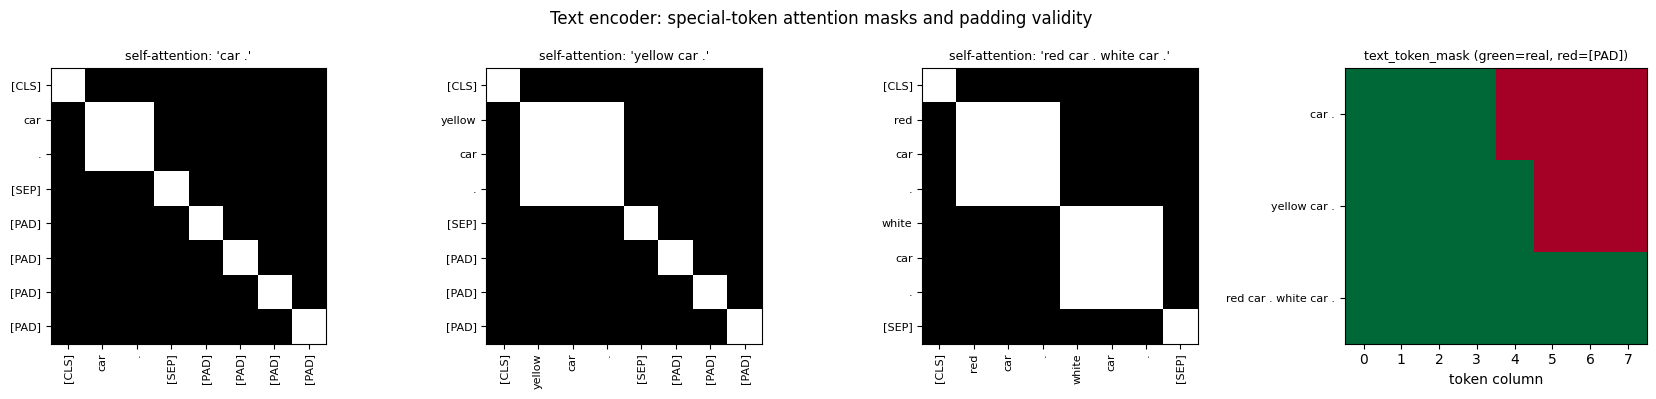

saved: /home/misaki/SC5006_Lab/MultiModalCounting/output/figures/text_masks.png and /home/misaki/SC5006_Lab/MultiModalCounting/output/figures/text_token_table.csv


In [5]:
import csv
 
EVID_CAPTIONS = ["car .", "yellow car .", "red car . white car ."]   # unequal lengths
EVID = encode_text(MODEL, EVID_CAPTIONS)
ids = EVID["input_ids"].cpu()
valid = EVID["text_token_mask"].cpu()
pos = EVID["position_ids"].cpu()
masks = EVID["text_self_attention_masks"].cpu()
L = ids.shape[1]
print(f"batch of {len(EVID_CAPTIONS)} captions padded to length {L};",
      "encoded_text:", tuple(EVID["encoded_text"].shape))
 
TOKEN_TABLE = []
for b, cap in enumerate(EVID_CAPTIONS):
    toks = MODEL.tokenizer.convert_ids_to_tokens(ids[b].tolist())
    n_real = len(MODEL.tokenizer(cap)["input_ids"])
    # Evidence checks: real columns are valid, padded columns are [PAD] and invalid.
    assert int(valid[b].sum()) == n_real
    assert all(t == "[PAD]" for t in toks[n_real:])
    assert not valid[b, n_real:].any()
    print(f"\n{cap!r}  real tokens={n_real}  padded={L - n_real}")
    print(f"  {'col':>3} {'token':>8} {'id':>6} {'valid':>6} {'pos':>4}")
    for j, (t, i, v, p) in enumerate(zip(toks, ids[b].tolist(), valid[b].tolist(), pos[b].tolist())):
        print(f"  {j:>3} {t:>8} {i:>6} {str(v):>6} {p:>4}")
        TOKEN_TABLE.append({"caption": cap, "column": j, "token": t, "id": i,
                            "valid": v, "position_id": p})
 
with open(OUTPUT / "text_token_table.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(TOKEN_TABLE[0]))
    writer.writeheader(); writer.writerows(TOKEN_TABLE)
 
fig, axes = plt.subplots(1, len(EVID_CAPTIONS) + 1, figsize=(4.2 * (len(EVID_CAPTIONS) + 1), 4))
for ax, b, cap in zip(axes, range(len(EVID_CAPTIONS)), EVID_CAPTIONS):
    toks = MODEL.tokenizer.convert_ids_to_tokens(ids[b].tolist())
    ax.imshow(masks[b].float(), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks(range(L)); ax.set_xticklabels(toks, rotation=90, fontsize=8)
    ax.set_yticks(range(L)); ax.set_yticklabels(toks, fontsize=8)
    ax.set_title(f"self-attention: {cap!r}", fontsize=9)
ax = axes[-1]
ax.imshow(valid.float(), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_yticks(range(len(EVID_CAPTIONS))); ax.set_yticklabels(EVID_CAPTIONS, fontsize=8)
ax.set_xticks(range(L)); ax.set_xlabel("token column")
ax.set_title("text_token_mask (green=real, red=[PAD])", fontsize=9)
fig.suptitle("Text encoder: special-token attention masks and padding validity")
fig.tight_layout()
fig.savefig(OUTPUT / "text_masks.png", dpi=170, bbox_inches="tight")
plt.show()
print("saved:", OUTPUT / "text_masks.png", "and", OUTPUT / "text_token_table.csv")

### Task 3 — ROIAlign visual exemplar tokens (15%)

Use pixel-space exemplar boxes and `roi_align` with `output_size=(1,1)`, `spatial_scale=1/8`, and `aligned=True`, then reshape the result to `(B,N,D)`.


In [6]:
def extract_exemplar_tokens(combined_features, exemplar_boxes):
    if combined_features.ndim != 4 or len(exemplar_boxes) != combined_features.shape[0]:
        raise ValueError("Expected features (B,D,H,W) and one (N,4) box tensor per image")
    counts = [len(boxes) for boxes in exemplar_boxes]
    if len(set(counts)) != 1 or counts[0] == 0:
        raise ValueError("This exercise expects the same positive exemplar count per image")
    tokens = roi_align(combined_features, boxes=exemplar_boxes, output_size=(1, 1),
                       spatial_scale=1/8, aligned=True).squeeze(-1).squeeze(-1)
    return tokens.reshape(combined_features.shape[0], counts[0], -1)

EXEMPLAR_TOKENS = extract_exemplar_tokens(COMBINED_FEATURES, [car_boxes_resized.to(COMBINED_FEATURES.device)])
print("resized exemplar:", car_boxes_resized.tolist())
print("ROIAlign exemplar token:", tuple(EXEMPLAR_TOKENS.shape))


resized exemplar: [[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]
ROIAlign exemplar token: (1, 1, 256)


### Task 4 — Similarity matrix calculation (15%)

Compute query–prompt dot products, mask padded prompt columns with `-inf`, and visualize the valid part of the similarity matrix.


similarity matrix: (1, 13400, 5)


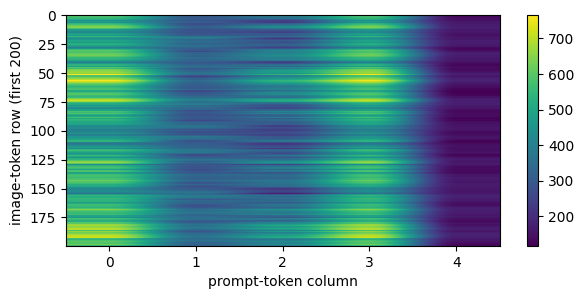

In [7]:
def calculate_similarity_matrix(query_features, prompt_features, prompt_mask):
    if query_features.ndim != 3 or prompt_features.ndim != 3:
        raise ValueError("Expected query (B,N,D) and prompt (B,T,D)")
    if query_features.shape[0] != prompt_features.shape[0] or query_features.shape[-1] != prompt_features.shape[-1]:
        raise ValueError("Batch and feature dimensions must agree")
    if prompt_mask.shape != prompt_features.shape[:2]:
        raise ValueError("Prompt mask must have shape (B,T)")
    logits = query_features @ prompt_features.transpose(-1, -2)
    return logits.masked_fill(~prompt_mask[:, None, :], float("-inf"))

IMAGE_TOKENS = COMBINED_FEATURES.flatten(2).transpose(1, 2)
PROMPT_TOKENS = torch.cat([TEXT_DICT["encoded_text"].to(IMAGE_TOKENS.device), EXEMPLAR_TOKENS], dim=1)
PROMPT_MASK = torch.cat([TEXT_DICT["text_token_mask"].to(IMAGE_TOKENS.device),
                         torch.ones((1, EXEMPLAR_TOKENS.shape[1]), dtype=torch.bool, device=IMAGE_TOKENS.device)], dim=1)
SIMILARITY = calculate_similarity_matrix(IMAGE_TOKENS, PROMPT_TOKENS, PROMPT_MASK)
print("similarity matrix:", tuple(SIMILARITY.shape))
plt.figure(figsize=(7, 3)); plt.imshow(SIMILARITY[0, :200].detach().cpu(), aspect="auto", cmap="viridis")
plt.xlabel("prompt-token column"); plt.ylabel("image-token row (first 200)"); plt.colorbar(); plt.show()


### Task 5 — Top-K encoder proposal selection (15%)

Reduce each proposal to its strongest prompt score, apply `topk` over proposals, and report the winning proposal IDs and prompt IDs.


In [8]:
def select_topk(similarity, k):
    if similarity.ndim != 3 or not 1 <= k <= similarity.shape[1]:
        raise ValueError("Expected (B,N,T) similarities and 1 <= k <= N")
    proposal_scores, prompt_ids = similarity.max(dim=-1)
    scores, proposal_ids = torch.topk(proposal_scores, k, dim=1)
    selected_prompt_ids = torch.gather(prompt_ids, 1, proposal_ids)
    return scores, proposal_ids, selected_prompt_ids

TOPK_SCORES, TOPK_PROPOSALS, TOPK_PROMPTS = select_topk(SIMILARITY, 10)
print("top-K proposal IDs:", TOPK_PROPOSALS.tolist())
print("winning prompt IDs:", TOPK_PROMPTS.tolist())


top-K proposal IDs: [[13396, 13395, 13394, 657, 13038, 326, 13257, 13172, 13241, 13261]]
winning prompt IDs: [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


### Task 6 — Shared integration experiment and results (25%)

Run the official model on all four prompt cases and include counts, localization plots at threshold `0.23`, component shapes, one ablation, runtime/hardware, and one failure case.

**TODO 6A — Prompt sensitivity experiment**

- create new text-only cases without changing the source images: `women → man` and `car → yellow car`;
- run each changed prompt through the live CountGD model using the same preprocessing and post-processing;
- report the changed captions, counts, scores, boxes, and localization plots; and
- compare each changed-prompt result with its original-prompt baseline.

Changed prompts require a live model forward pass. Run fresh inference for `man` and `yellow car`; do not reuse predictions from another query.


women_text 'women' LIVE (900, 256) (900, 4) count= 5 time=4.11s
car_text 'car' LIVE (900, 256) (900, 4) count= 16 time=3.99s
car_exemplar '' LIVE (900, 256) (900, 4) count= 16 time=4.43s
car_multimodal 'car' LIVE (900, 256) (900, 4) count= 16 time=4.38s


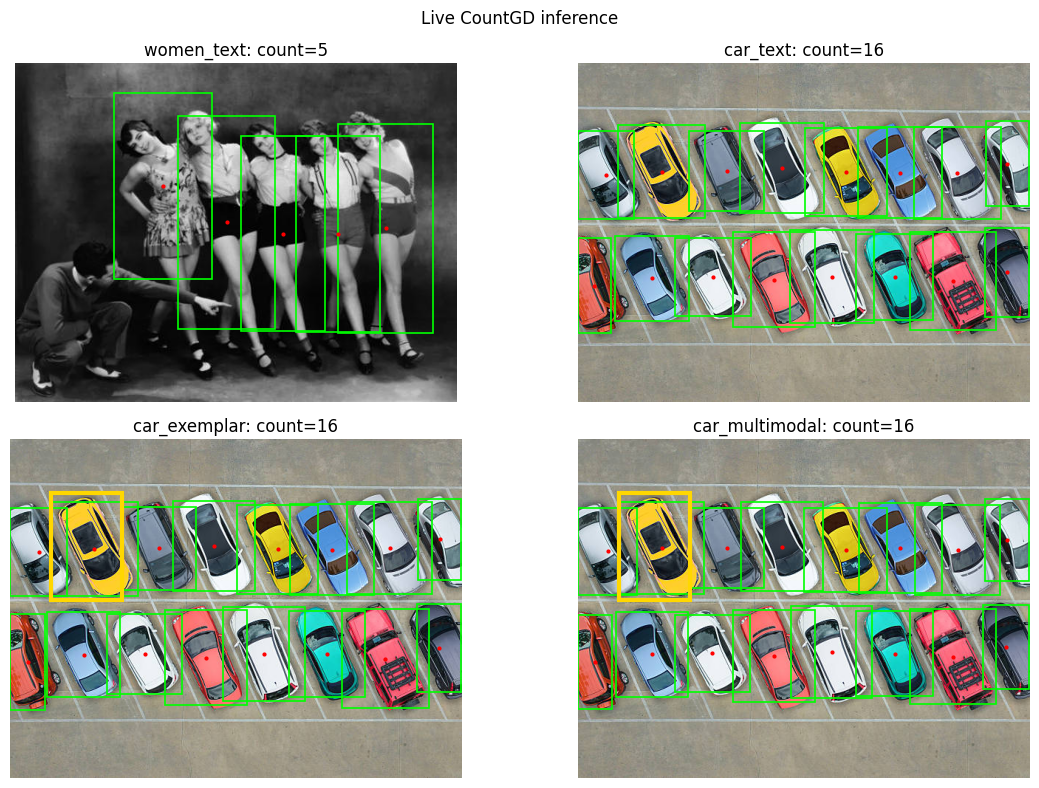

In [9]:
# Task 6 reuses prepare_case and preprocess_case from Section 0.
# The official forward pass internally executes the components studied in Tasks 1–5.
def run_countgd(model, image_name, query="", exemplar_boxes=()):
    case_name = f"{Path(image_name).stem}_{query or 'exemplar'}".replace(" ", "_")
    case = prepare_case(case_name, image_name, text=query, boxes=exemplar_boxes)
    image_tensor, boxes = preprocess_case(case)
    model.drop_text = case["mode"] == "exemplar only"
    with torch.inference_mode():
        output = model(
            image_tensor.unsqueeze(0).to(DEVICE),
            [boxes.to(DEVICE)],
            [torch.tensor([0], device=DEVICE)],
            captions=[case["caption"]],
        )
    assert tuple(output["pred_logits"].shape[1:]) == (900, 256)
    assert tuple(output["pred_boxes"].shape[1:]) == (900, 4)
    raw = {
        "confidences": output["pred_logits"][0].sigmoid().cpu().numpy().astype(np.float32),
        "boxes": output["pred_boxes"][0].cpu().numpy().astype(np.float32),
        "image_size": (case["image"].height, case["image"].width),
    }
    return case, raw

def postprocess_countgd(raw, threshold=0.23):
    confidences, boxes = raw["confidences"], raw["boxes"]
    finite = np.isfinite(confidences).all(1) & np.isfinite(boxes).all(1)
    scores = np.where(finite[:, None], confidences, -np.inf).max(1)
    keep = finite & (scores > threshold)
    scores, boxes = scores[keep], boxes[keep]
    h, w = raw["image_size"]
    cx, cy, bw, bh = boxes.T
    xyxy = np.column_stack([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
    xyxy[:, [0, 2]] = np.clip(xyxy[:, [0, 2]], 0, w-1)
    xyxy[:, [1, 3]] = np.clip(xyxy[:, [1, 3]], 0, h-1)
    centers = np.column_stack([(xyxy[:, 0]+xyxy[:, 2])/2, (xyxy[:, 1]+xyxy[:, 3])/2])
    return {"scores": scores, "boxes": xyxy, "centers": centers, "count": len(scores)}

def predict_countgd(image_name, query="", exemplar_boxes=(), threshold=0.23):
    case, raw = run_countgd(MODEL, image_name, query, exemplar_boxes)
    return {"case": case, "raw": raw, "result": postprocess_countgd(raw, threshold)}

# Text inference needs only the image filename and query. Boxes are optional for exemplar modes.
REQUESTS = [
    ("women_text", "women.jpg", "women", ()),
    ("car_text", "car.jpg", "car", ()),
    ("car_exemplar", "car.jpg", "", [[55, 72, 151, 218]]),
    ("car_multimodal", "car.jpg", "car", [[55, 72, 151, 218]]),
]

PREDICTIONS = {}
for name, image_name, query, exemplar_boxes in REQUESTS:
    t0 = time.time()
    PHRASE_THRESHOLD = 0.50
    prediction = predict_countgd(image_name, query, exemplar_boxes, threshold=PHRASE_THRESHOLD)
    PREDICTIONS[name] = prediction
    print(name, repr(query), "LIVE", prediction["raw"]["confidences"].shape,
          prediction["raw"]["boxes"].shape, "count=", prediction["result"]["count"],
          f"time={time.time()-t0:.2f}s")

# Keep these aliases for the prompt-sensitivity experiment below.
RAW = {name: value["raw"] for name, value in PREDICTIONS.items()}
RESULTS = {name: value["result"] for name, value in PREDICTIONS.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, prediction) in zip(axes.flat, PREDICTIONS.items()):
    case, result = prediction["case"], prediction["result"]
    ax.imshow(case["image"])
    for score, (x1, y1, x2, y2), (x, y) in zip(result["scores"], result["boxes"], result["centers"]):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="lime", lw=1.2))
        ax.plot(x, y, "r.", ms=4)
    for x1, y1, x2, y2 in case["boxes"]:
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="gold", lw=3))
    ax.set_title(f"{name}: count={result['count']}")
    ax.axis("off")
fig.suptitle("Live CountGD inference")
fig.tight_layout()
fig.savefig(OUTPUT / "official_countgd_car_women_tests.png", dpi=170, bbox_inches="tight")
plt.show()


women_as_man 'man .' tokens= ['man'] count= 1
car_as_yellow_car 'yellow car .' tokens= ['yellow', 'car'] count= 2


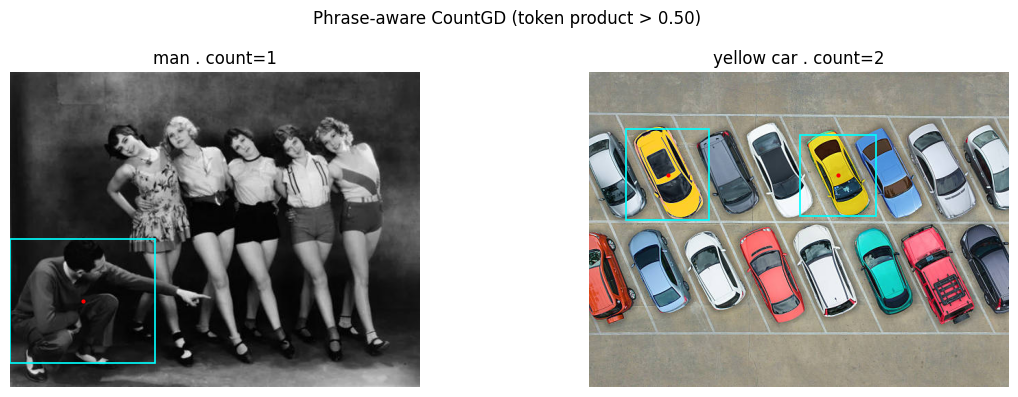

In [10]:
PROMPT_VARIANTS = [
    prepare_case("women_as_man", "women.jpg", text="man"),
    prepare_case("car_as_yellow_car", "car.jpg", text="yellow car"),
]

def phrase_token_indices(model, caption):
    encoded = model.tokenizer(caption)
    tokens = model.tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    ignored = set(model.tokenizer.all_special_tokens) | {".", ",", ";", ":", "!", "?"}
    indices = [index for index, token in enumerate(tokens) if token not in ignored]
    if not indices:
        raise ValueError(f"No meaningful text tokens found in {caption!r}")
    return indices, [tokens[index] for index in indices]

def postprocess_phrase_query(raw, model, caption, threshold=0.50):
    indices, tokens = phrase_token_indices(model, caption)
    phrase_scores = raw["confidences"][:, indices].prod(axis=1, dtype=np.float32)
    phrase_raw = {**raw, "confidences": phrase_scores[:, None]}
    result = postprocess_countgd(phrase_raw, threshold)
    result["phrase_tokens"] = tokens
    return result

def evaluate_prompt_variants(model, prompt_cases, threshold=0.50):
    if model is None:
        raise RuntimeError("Changed prompts require fresh live-model inference.")
    evaluated = {}
    for case in prompt_cases:
        query = case["caption"][:-2] if case["caption"].endswith(" .") else case["caption"]
        _, raw = run_countgd(model, case["image_name"], query, case["boxes"])
        result = postprocess_phrase_query(raw, model, case["caption"], threshold)
        evaluated[case["name"]] = {"raw": raw, "result": result}
    return evaluated

PHRASE_THRESHOLD = 0.50
PROMPT_RESULTS = evaluate_prompt_variants(MODEL, PROMPT_VARIANTS, PHRASE_THRESHOLD)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, case in zip(axes, PROMPT_VARIANTS):
    result = PROMPT_RESULTS[case["name"]]["result"]
    ax.imshow(case["image"])
    for score, (x1, y1, x2, y2), (x, y) in zip(
        result["scores"], result["boxes"], result["centers"]
    ):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="cyan", lw=1.2))
        ax.plot(x, y, "r.", ms=4)
    ax.set_title(f"{case['caption']} count={result['count']}")
    ax.axis("off")
    print(case["name"], repr(case["caption"]),
          "tokens=", result["phrase_tokens"], "count=", result["count"])
fig.suptitle(f"Phrase-aware CountGD (token product > {PHRASE_THRESHOLD:.2f})")
fig.tight_layout()
fig.savefig(OUTPUT / "countgd_changed_text_prompts.png", dpi=170, bbox_inches="tight")
plt.show()

In [18]:
import json
 
PAIRS = [("women.jpg", "women", "man"), ("car.jpg", "car", "yellow car")]
TABLE = []
for image_name, original, changed in PAIRS:
    for kind, query in (("original", original), ("changed", changed)):
        t0 = time.time()
        _, raw = run_countgd(MODEL, image_name, query)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        seconds = time.time() - t0
        caption = f"{query} ."
        official = postprocess_countgd(raw, 0.23)
        prod_023 = postprocess_phrase_query(raw, MODEL, caption, 0.23)
        prod_050 = postprocess_phrase_query(raw, MODEL, caption, 0.50)
        TABLE.append({
            "image": image_name, "kind": kind, "prompt": query,
            "tokens": prod_050["phrase_tokens"],
            "max@0.23": official["count"],
            "prod@0.23": prod_023["count"],
            "prod@0.50": prod_050["count"],
            "top_prod_score": float(prod_050["scores"].max()) if prod_050["count"] else None,
            "seconds": round(seconds, 3),
        })
 
print("Table 3 — LIVE inference, fresh forward pass per prompt")
print(f"{'image':<10} {'kind':<9} {'prompt':<11} {'tokens':<20} "
      f"{'max@0.23':>8} {'prod@0.23':>9} {'prod@0.50':>9} {'time(s)':>8}")
for r in TABLE:
    print(f"{r['image']:<10} {r['kind']:<9} {r['prompt']:<11} {str(r['tokens']):<20} "
          f"{r['max@0.23']:>8} {r['prod@0.23']:>9} {r['prod@0.50']:>9} {r['seconds']:>8}")
 
for r in TABLE:
    if len(r["tokens"]) == 1:
        assert r["max@0.23"] == r["prod@0.23"], r
 
with open(OUTPUT / "table3_prompt_comparison.json", "w") as f:
    json.dump(TABLE, f, indent=2)
with open(OUTPUT / "table3_prompt_comparison.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(TABLE[0]))
    writer.writeheader()
    writer.writerows({**r, "tokens": " ".join(r["tokens"])} for r in TABLE)
print("saved:", OUTPUT / "table3_prompt_comparison.json")

Table 3 — LIVE inference, fresh forward pass per prompt
image      kind      prompt      tokens               max@0.23 prod@0.23 prod@0.50  time(s)
women.jpg  original  women       ['women']                   5         5         5    3.955
women.jpg  changed   man         ['man']                     4         4         1    3.738
car.jpg    original  car         ['car']                    16        16        16     3.99
car.jpg    changed   yellow car  ['yellow', 'car']          16        15         2    3.832
saved: /home/misaki/SC5006_Lab/MultiModalCounting/output/figures/table3_prompt_comparison.json


Prompt-sensitivity probes — LIVE inference, fresh forward pass per prompt
group    prompt      tokens            GT max@.23 prod@.50         max band (w)        prod band (w)
----------------------------------------------------------------------------------------------------
wording  car         car               16      16       16  0.056-0.737 (0.682)  0.056-0.737 (0.682)
wording  cars        cars              16      16       16   0.069-0.719 (0.65)   0.069-0.719 (0.65)
wording  vehicle     vehicle           16      16       16  0.062-0.659 (0.597)  0.062-0.659 (0.597)
wording  automobile  automobile        16      16       16  0.072-0.697 (0.625)  0.072-0.697 (0.625)
wording  women       women              5       5        5  0.187-0.852 (0.665)  0.187-0.852 (0.665)
wording  woman       woman              5       5        5  0.146-0.810 (0.663)  0.146-0.810 (0.663)
wording  lady        lady               5       5        5  0.137-0.858 (0.721)  0.137-0.858 (0.721)
colour   yellow c

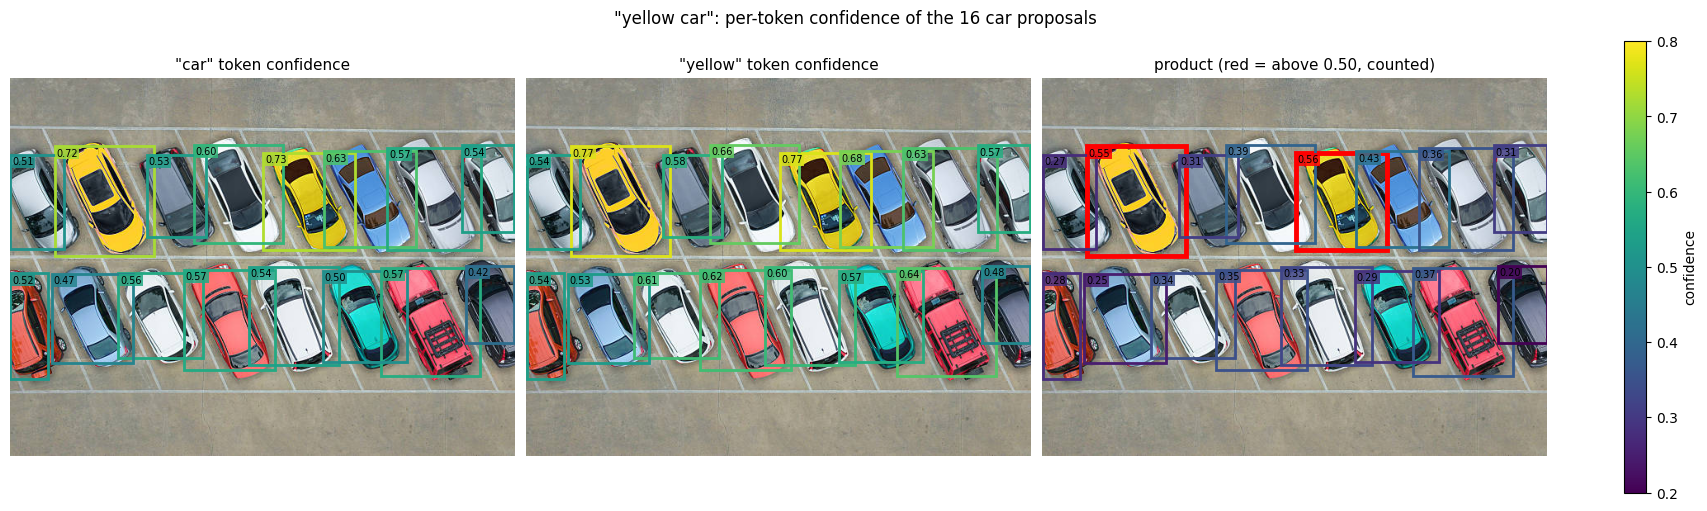

In [ ]:
import csv

PROBES = [
    # synonyms / wording: same objects, different category word
    ("car.jpg",   "car",         16,   "wording"),
    ("car.jpg",   "cars",        16,   "wording"),
    ("car.jpg",   "vehicle",     16,   "wording"),
    ("car.jpg",   "automobile",  16,   "wording"),
    ("women.jpg", "women",       5,    "wording"),
    ("women.jpg", "woman",       5,    "wording"),
    ("women.jpg", "lady",        5,    "wording"),
    # colour attributes: should select a subset
    ("car.jpg",   "yellow car",  2, "colour"),
    ("car.jpg",   "red car",     3, "colour"),
    ("car.jpg",   "white car",   3, "colour"),
    ("car.jpg",   "blue car",    2, "colour"),
    # controls: attributes that EVERY car satisfies, so the count should stay 16
    ("car.jpg",   "parked car",  16,   "control"),
    ("car.jpg",   "shiny car",   16,   "control"),
]

SPECIAL = set(MODEL.tokenizer.all_special_tokens)
PUNCT = {".", ",", "?", "!", ";", ":"}

def token_scores(raw, query):
    """Per-proposal max score and product-of-meaningful-tokens score."""
    ids = MODEL.tokenizer(f"{query} .")["input_ids"]
    toks = MODEL.tokenizer.convert_ids_to_tokens(ids)
    keep = [i for i, t in enumerate(toks) if t not in SPECIAL and t not in PUNCT]
    conf = raw["confidences"]
    return conf.max(1), conf[:, keep].prod(1), [toks[i] for i in keep]

def band(scores, gt):
    """Thresholds t with lo <= t < hi give count == gt (count uses score > t)."""
    if gt is None or gt <= 0 or gt >= len(scores):
        return None
    s = np.sort(scores)[::-1]
    return float(s[gt]), float(s[gt - 1])

PROBE_ROWS = []
for image_name, query, gt, group in PROBES:
    t0 = time.time()
    _, raw = run_countgd(MODEL, image_name, query)
    seconds = time.time() - t0
    s_max, s_prod, toks = token_scores(raw, query)
    n_max, n_prod = int((s_max > 0.23).sum()), int((s_prod > 0.50).sum())

    assert n_prod == postprocess_phrase_query(raw, MODEL, f"{query} .", 0.50)["count"], query
    b_max, b_prod = band(s_max, gt), band(s_prod, gt)
    PROBE_ROWS.append({
        "group": group, "image": image_name, "prompt": query, "tokens": " ".join(toks),
        "gt": gt, "max@0.23": n_max, "prod@0.50": n_prod,
        "max_band": None if b_max is None else f"{b_max[0]:.3f}-{b_max[1]:.3f}",
        "max_band_width": None if b_max is None else round(b_max[1] - b_max[0], 3),
        "prod_band": None if b_prod is None else f"{b_prod[0]:.3f}-{b_prod[1]:.3f}",
        "prod_band_width": None if b_prod is None else round(b_prod[1] - b_prod[0], 3),
        "seconds": round(seconds, 2),
    })

print("Prompt-sensitivity probes — LIVE inference, fresh forward pass per prompt")
hdr = f"{'group':<8} {'prompt':<11} {'tokens':<16} {'GT':>3} {'max@.23':>7} {'prod@.50':>8} {'max band (w)':>20} {'prod band (w)':>20}"
print(hdr); print("-" * len(hdr))
for r in PROBE_ROWS:
    mb = "-" if r["max_band"] is None else f"{r['max_band']} ({r['max_band_width']})"
    pb = "-" if r["prod_band"] is None else f"{r['prod_band']} ({r['prod_band_width']})"
    gt = "?" if r["gt"] is None else r["gt"]
    print(f"{r['group']:<8} {r['prompt']:<11} {r['tokens']:<16} {gt:>3} {r['max@0.23']:>7} {r['prod@0.50']:>8} {mb:>20} {pb:>20}")

with open(OUTPUT / "prompt_probes.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(PROBE_ROWS[0]))
    writer.writeheader(); writer.writerows(PROBE_ROWS)
print("saved:", OUTPUT / "prompt_probes.csv")


case, raw = run_countgd(MODEL, "car.jpg", "yellow car")
conf, boxes = raw["confidences"], raw["boxes"]
toks = MODEL.tokenizer.convert_ids_to_tokens(MODEL.tokenizer("yellow car .")["input_ids"])
y_col, c_col = toks.index("yellow"), toks.index("car")
idx = np.argsort(-conf[:, c_col])[:16]                      # the 16 car proposals
h, w = raw["image_size"]
cx, cy, bw, bh = boxes[idx].T
x1, y1 = np.clip((cx - bw/2) * w, 0, w-1), np.clip((cy - bh/2) * h, 0, h-1)
x2, y2 = np.clip((cx + bw/2) * w, 0, w-1), np.clip((cy + bh/2) * h, 0, h-1)

car_s, yel_s = conf[idx, c_col], conf[idx, y_col]
panels = [('"car" token confidence', car_s),
          ('"yellow" token confidence', yel_s),
          ('product (red = above 0.50, counted)', car_s * yel_s)]
cmap, norm = plt.cm.viridis, plt.Normalize(0.2, 0.8)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
for p, (ax, (title, vals)) in enumerate(zip(axes, panels)):
    ax.imshow(case["image"])
    for a, b, c, d, v in zip(x1, y1, x2, y2, vals):
        counted = p == 2 and v > 0.50
        color = "red" if counted else cmap(norm(v))
        ax.add_patch(Rectangle((a, b), c - a, d - b, fill=False, ec=color, lw=3.5 if counted else 2))
        ax.text(a + 2, b + 2, f"{v:.2f}", fontsize=7, color="black", va="top",
                bbox=dict(facecolor=color, alpha=0.85, pad=1, lw=0))
    ax.set_title(title, fontsize=11)
    ax.axis("off")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.015, label="confidence")
fig.suptitle('"yellow car": per-token confidence of the 16 car proposals')
fig.savefig(OUTPUT / "yellow_car_token_map.png", dpi=170, bbox_inches="tight")
plt.show()